# Speech Command Recognition

Autor: Alberto Calabrese

Mail: alberto.calabrese.2@studenti.unipd.it

# Setup

In [1]:
import os
import librosa
import numpy as np
import librosa.display
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import re
import hashlib
import tensorflow as tf
from collections import defaultdict, Counter
from keras import layers, models
import pickle
import json
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import regularizers
import time
from sklearn.preprocessing import label_binarize, MinMaxScaler
from keras.saving import register_keras_serializable

2025-07-25 08:51:51.900064: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753433512.106190      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753433512.162250      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
device_name = tf.test.gpu_device_name()
if device_name:
    print(f"GPU detected: {device_name}")
else:
    print("GPU not found. Go to Runtime > Change runtime type > GPU")

GPU detected: /device:GPU:0


I0000 00:00:1753433526.706394      19 gpu_device.cc:2022] Created device /device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [3]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

In [4]:
BASE_PATH = "/kaggle/input/speechcommanddataset"
PROCESSED_DATA_DIR = "/kaggle/input/speechcommanddataset/processed_dataset"
OUTPUT_DATA_DIR = "/kaggle/working"

# Data Preprocessing

Do not execute the following code since it's already executed locally


In [5]:
MAX_NUM_WAVS_PER_CLASS = 2**27 - 1  # ~134M

def which_set(filename, validation_percentage, testing_percentage):
    """
    Determines which dataset partition a file should belong to.
    This function follows the indications of the dataset creators.
    Args:
    filename: File path of the data sample.
    validation_percentage: How much of the data set to use for validation.
    testing_percentage: How much of the data set to use for testing.

    Returns:
    String, one of 'training', 'validation', or 'testing'.
    """
    base_name = os.path.basename(filename)
    hash_name = re.sub(r'_nohash_.*$', '', base_name)
    hash_name_hashed = hashlib.sha1(hash_name.encode()).hexdigest()
    percentage_hash = ((int(hash_name_hashed, 16) %
                        (MAX_NUM_WAVS_PER_CLASS + 1)) *
                        (100.0 / MAX_NUM_WAVS_PER_CLASS))
    if percentage_hash < validation_percentage:
        result = 'val'
    elif percentage_hash < (testing_percentage + validation_percentage):
        result = 'test'
    else:
        result = 'train'
    return result

In [6]:
class SpeechPreprocessor:
    def __init__(self, dataset_path, output_path="Data/processed_dataset",
                 sample_rate=16000, n_mels=40, frame_size=0.025, frame_step=0.010,
                 noise_prob=0.3):
        """
        Initializes the SpeechPreprocessor class.

        Args:
            dataset_path (str): Path to the dataset folder.
            output_path (str): Path to the output folder.
            sample_rate (int): Sampling rate of the audio files.
            n_mels (int): Number of Mel bands to generate.
            frame_size (float): Size of the frame window in seconds.
            frame_step (float): Size of the frame step in seconds.
        """
        self.dataset_path = dataset_path
        self.output_path = output_path
        self.sample_rate = sample_rate
        self.n_mels = n_mels
        self.frame_size = frame_size
        self.frame_step = frame_step
        self.noise_prob = noise_prob
        self.noise_samples = self._load_noise_samples()

        # Ensure output directories exist
        os.makedirs(self.output_path, exist_ok=True)
        for split in ["train", "val", "test"]:
            os.makedirs(f"{self.output_path}/{split}", exist_ok=True)
        print(f"Initialized SpeechPreprocessor with dataset path: {self.dataset_path} and output path: {self.output_path}")

    def _load_noise_samples(self):
        """
        Loads background noise samples from the dataset.
        Returns:
            list: List of noise samples.
        """
        noise_dir = os.path.join(self.dataset_path, "_background_noise_")
        noises = []
        for fname in os.listdir(noise_dir):
            if fname.endswith(".wav"):
                noise_path = os.path.join(noise_dir, fname)
                y, _ = librosa.load(noise_path, sr=self.sample_rate)
                noises.append(y)
        return noises

    def _time_shift(self, audio, shift_max=0.1):
        """
        Applies a random time shift to the audio signal.
        Args:
            audio (np.ndarray): Audio signal to be shifted.
            shift_max (float): Maximum shift in seconds.
        Returns:
            np.ndarray: Time-shifted audio signal.
        """
        shift = int(random.uniform(-shift_max, shift_max) * self.sample_rate)
        if shift > 0:
            audio = np.pad(audio, (shift, 0), mode='constant')[:len(audio)]
        elif shift < 0:
            audio = np.pad(audio, (0, -shift), mode='constant')[-shift:]
        return audio

    def _spec_augment(self, spectrogram, freq_mask_param=3, time_mask_param=8):
        """
        Applies SpecAugment to the spectrogram.
        Args:
            spectrogram (np.ndarray): Input spectrogram.
            freq_mask_param (int): Maximum frequency mask size.
            time_mask_param (int): Maximum time mask size.
        Returns:
            np.ndarray: Augmented spectrogram.
        """
        spec = np.copy(spectrogram)
        num_mel_channels = spec.shape[0]
        num_time_steps = spec.shape[1]

        # Frequency masking
        for _ in range(1):
            f = random.randint(0, freq_mask_param)
            f0 = random.randint(0, num_mel_channels - f)
            spec[f0:f0 + f, :] = 0

        # Time masking
        for _ in range(1):
            t = random.randint(0, time_mask_param)
            t0 = random.randint(0, num_time_steps - t)
            spec[:, t0:t0 + t] = 0

        return spec

    def _add_noise(self, audio):
        """
        Adds random background noise to the audio signal.
        Args:
            audio (np.ndarray): Audio signal to which noise will be added.
        Returns:
            np.ndarray: Audio signal with added noise.
        """
        # If no noise samples are loaded or noise probability is not met, return original audio
        if not self.noise_samples or random.random() > self.noise_prob:
            return audio

        noise = random.choice(self.noise_samples)
        if len(noise) > len(audio):
            start_idx = random.randint(0, len(noise) - len(audio))
            noise = noise[start_idx:start_idx + len(audio)]
        else:
            noise = np.pad(noise, (0, len(audio) - len(noise)))

        # Random noise level between 0.1x and 0.4x of audio signal
        noise_level = random.uniform(0.1, 0.4)
        return audio + noise_level * noise

    def _get_spectrogram(self, filepath, add_noise=False, apply_time_shift=False, apply_spec_augment=False,
                        time_shift_prob=0.5, spec_augment_prob=0.5):
        """
        Converts a .wav file into a log Mel spectrogram.

        Args:
            filepath (str): Path to the .wav file.
            add_noise (bool): Whether to add background noise to the audio.

        Returns:
            np.ndarray: Log Mel spectrogram of the audio file.
        """
        y, sr = librosa.load(filepath, sr=self.sample_rate)

        if apply_time_shift and random.random() < time_shift_prob:
            y = self._time_shift(y)

        if add_noise:
            y = self._add_noise(y)

        spectrogram = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=self.n_mels,
            hop_length=int(self.frame_step * sr),
            n_fft=int(self.frame_size * sr)
        )
        spectrogram = librosa.power_to_db(spectrogram, ref=np.max)

        if apply_spec_augment and random.random() < spec_augment_prob:
            spectrogram = self._spec_augment(spectrogram)

        # Pad or truncate to fixed width
        target_width = 101
        if spectrogram.shape[1] < target_width:
            spectrogram = np.pad(spectrogram, ((0, 0), (0, target_width - spectrogram.shape[1])), mode="constant")
        else:
            spectrogram = spectrogram[:, :target_width]

        return spectrogram


    def process_audio_files(self):
        """
        Processes all audio files and applies dataset partitioning.
        The processed spectrograms are saved in the output directory.
        The dataset partitioning is done using the official method from the dataset.
        The processed dataset will have the following structure:
        processed_dataset/
        ├── train/ # Training set
        │   ├── class1/
        │   │   ├── file1.npy
        │   │   ├── file2.npy
        │   │   └── ...
        │   ├── class2/
        │   └── ...
        ├── val/ # Validation set
        │   ├── class1/
        │   ├── class2/
        │   └── ...
        └── test/ # Testing set
            ├── class1/
            ├── class2/
            └── ...
        Data augmentation is applied only to the training set with noise addition, time shifting and spec augment.
        """
        print("Processing audio files...")

        noise_count = 0
        time_shift_count = 0
        spec_augment_count = 0

        for label in tqdm(os.listdir(self.dataset_path)):
            label_path = os.path.join(self.dataset_path, label)
            # Skip if the path is not a directory or the label is _background_noise_
            if not os.path.isdir(label_path) or label == "_background_noise_":
                continue

            for filename in os.listdir(label_path):
                if not filename.endswith(".wav"):
                    continue

                filepath = os.path.join(label_path, filename)

                # Determine dataset partition
                dataset_type = which_set(filename, 10, 10)

                # Add noise only for training set
                is_train = (dataset_type == "train")

                # Check if the spectrogram is already saved
                output_dir = os.path.join(self.output_path, dataset_type, label)
                os.makedirs(output_dir, exist_ok=True)

                output_file = os.path.join(output_dir, filename.replace(".wav", ".npy"))

                if os.path.exists(output_file):
                    continue  # Skip if the file already exists

                apply_noise = is_train and (random.random() < self.noise_prob)
                apply_time_shift = is_train and (random.random() < 0.3)
                apply_spec_augment = is_train and (random.random() < 0.3)

                # Convert to spectrogram
                spectrogram = self._get_spectrogram(
                    filepath, apply_noise, is_train, is_train,
                    time_shift_prob=0.3, spec_augment_prob=0.3
                )

                # Normalize
                spectrogram = (spectrogram - np.mean(spectrogram)) / np.std(spectrogram)

                # Save spectrogram
                np.save(output_file, spectrogram)

                # Log the augmented files
                if apply_noise:
                    noise_count += 1
                if apply_time_shift:
                    time_shift_count += 1
                if apply_spec_augment:
                    spec_augment_count += 1

        print("Data processing complete!")

        # Stats summary
        total_processed = sum(
            len([f for f in files if f.endswith(".npy")])
            for split in ["train", "val", "test"]
            for root, _, files in os.walk(os.path.join(self.output_path, split))
        )

        train_total = sum(
            len([f for f in files if f.endswith(".npy")])
            for root, _, files in os.walk(os.path.join(self.output_path, "train"))
        )

        if total_processed > 0:
            print(f"\nSummary of Preprocessing:")
            print(f"- Total samples processed: {total_processed}")

        if train_total > 0:
            print(f"- Total training samples: {train_total}")
            print(f"- Training samples with noise: {noise_count} ({(noise_count / train_total) * 100:.2f}%)")
            print(f"- Training samples with time shift: {time_shift_count} ({(time_shift_count / train_total) * 100:.2f}%)")
            print(f"- Training samples with SpecAugment: {spec_augment_count} ({(spec_augment_count / train_total) * 100:.2f}%)\n")



    def visualize_random_sample(self):
        sample_class = random.choice(os.listdir(f"{self.output_path}/train"))
        sample_file = random.choice(os.listdir(f"{self.output_path}/train/{sample_class}"))

        spectrogram = np.load(f"{self.output_path}/train/{sample_class}/{sample_file}")

        plt.figure(figsize=(10, 4))
        librosa.display.specshow(spectrogram, sr=self.sample_rate,
                                 hop_length=int(self.frame_step * self.sample_rate),
                                 x_axis="time", y_axis="mel")
        plt.colorbar(format="%+2.0f dB")
        plt.title(f"Spectrogram of {sample_file}")
        plt.show()

In [7]:
def preprocess():
    # Path to the dataset
    raw_data_dir = "Data/speech_commands_v0.02"  # Raw dataset path

    # Create the preprocessor instance
    processor = SpeechPreprocessor(raw_data_dir)

    # Process all audio files
    processor.process_audio_files()

    # Visualize a sample spectrogram as a sanity check
    processor.visualize_random_sample()

# UNCOMMENT THE FOLLOWING LINE WHEN YOU WANT TO RUN THE NOTEBOOK WITH THE ORIGINAL DATASET AND PREPROCESS IT HERE.
# preprocess()

# Models

### Data Loading and Utils

In [8]:
def get_class_weights(train_path):
    """
    Computes class weights based on the number of .wav files in each class directory.

    Args:
        train_path (str): Path to the train dataset folder.

    Returns:
        class_weights (dict): {class_index: weight}
        label_to_index (dict): {label_name: index}
        index_to_label (dict): {index: label_name}
    """
    # List class names
    class_names = sorted([
        d for d in os.listdir(train_path)
        if os.path.isdir(os.path.join(train_path, d))
    ])

    label_to_index = {label: idx for idx, label in enumerate(class_names)}
    index_to_label = {idx: label for label, idx in label_to_index.items()}

    class_counts = Counter()
    for label in class_names:
        label_dir = os.path.join(train_path, label)
        num_files = len([f for f in os.listdir(label_dir) if f.endswith(".npy")])
        class_counts[label] = num_files

    y_all = np.concatenate([[label] * class_counts[label] for label in class_names])

    weights = compute_class_weight(class_weight="balanced", classes=np.array(class_names), y=y_all)
    class_weights = {label_to_index[class_names[i]]: weights[i] for i in range(len(class_names))}

    return class_weights, label_to_index, index_to_label

train_path = PROCESSED_DATA_DIR + "/train"

class_weights, label_to_index, index_to_label = get_class_weights(train_path)

In [9]:
def load_dataset(split_path, label_to_index, input_shape=(40, 101), shuffle=True):
    data = []
    labels = []

    for label in os.listdir(split_path):
        label_path = os.path.join(split_path, label)
        if not os.path.isdir(label_path):
            continue

        for fname in os.listdir(label_path):
            if not fname.endswith(".npy"):
                continue

            file_path = os.path.join(label_path, fname)
            spectrogram = np.load(file_path).astype(np.float32)

            # Ensure shape matches
            if spectrogram.shape != input_shape:
                print(f"Skipping {file_path} due to shape mismatch: {spectrogram.shape}")
                continue

            data.append(spectrogram)
            labels.append(label_to_index[label])


    data = np.array(data)[..., np.newaxis]  # Add channel dim
    labels = np.array(labels)

    dataset = tf.data.Dataset.from_tensor_slices((data, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(data))

    return dataset, data, labels

In [10]:
train_ds, _, _ = load_dataset(os.path.join(PROCESSED_DATA_DIR, "train"), label_to_index)
val_ds, _, _ = load_dataset(os.path.join(PROCESSED_DATA_DIR, "val"), label_to_index, shuffle=False)
test_ds, X_test, y_test = load_dataset(os.path.join(PROCESSED_DATA_DIR, "test"), label_to_index, shuffle=False)


BATCH_SIZE = 64
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1753433984.974184      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [11]:
def save_and_plot_results(history, model, model_name, saving_dir):
    """
    Save the model training hisory, his metadata and plots results for accuracy and loss
    Args:
        history
        model
        model_name (str)
        saving_dir (str)
    """
    print(f"\n--- Saving results for model: {model_name} ---")
    
    os.makedirs(saving_dir, exist_ok=True)

    history_dict = history.history

    plt.figure(figsize=(10, 6))
    plt.plot(history_dict['loss'], label='Training Loss', marker='o')
    plt.plot(history_dict['val_loss'], label='Validation Loss', marker='o')
    plt.title(f"Loss: {model_name.replace('_', ' ').title()}", fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    loss_path = os.path.join(saving_dir, f"{model_name}_loss.png")
    plt.savefig(loss_path)
    plt.show()
    print(f"Loss plot saved to {loss_path}")

    plt.figure(figsize=(10, 6))
    plt.plot(history_dict['accuracy'], label='Training Accuracy', marker='o')
    plt.plot(history_dict['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.title(f"Accuracy: {model_name.replace('_', ' ').title()}", fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    accuracy_path = os.path.join(saving_dir, f"{model_name}_accuracy.png")
    plt.savefig(accuracy_path)
    plt.show()
    print(f"Accuracy plot saved to {accuracy_path}")

    history_path = os.path.join(saving_dir, "training_history.pkl")
    with open(history_path, "wb") as f:
        pickle.dump(history_dict, f)
    print(f"Training history saved to {history_path}")

    best_epoch_idx = np.argmax(history_dict['val_accuracy'])
    best_train_acc = history_dict['accuracy'][best_epoch_idx]
    best_val_acc = history_dict['val_accuracy'][best_epoch_idx]
    effective_epochs = best_epoch_idx + 1

    metadata = {
        "model_name": model_name,
        "epochs_trained": int(effective_epochs),
        "best_train_acc": round(float(best_train_acc), 4),
        "best_val_acc": round(float(best_val_acc), 4),
        "input_shape": list(model.input_shape),
        "output_shape": list(model.output_shape),
        "num_params": int(model.count_params())
    }
    metadata_path = os.path.join(saving_dir, f"metadata_{model_name}.json")
    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=4)
    print(f"Metadata saved to {metadata_path}")

## Baseline CNN

In [12]:
def baseline_cnn(input_shape=(40, 101, 1), num_classes = len(label_to_index)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    lr = 1e-3
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    loss = 'sparse_categorical_crossentropy'
    metrics = ['accuracy']
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    return model

In [13]:
model = baseline_cnn(input_shape=(40, 101, 1), num_classes=len(label_to_index))

model_name = "baseline_cnn"
saving_dir = f"{OUTPUT_DATA_DIR}/{model_name}"
os.makedirs(saving_dir, exist_ok=True)

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1)

checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(saving_dir, f"{model_name}_best.keras"),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max')

lr_scheduler_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping_cb, checkpoint_cb, lr_scheduler_cb])

Epoch 1/20


I0000 00:00:1753434104.724174      59 service.cc:148] XLA service 0x7ed9a000eaa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753434104.724814      59 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1753434105.072638      59 cuda_dnn.cc:529] Loaded cuDNN version 90300


  16/1326 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.0373 - loss: 9.2152 

I0000 00:00:1753434108.923574      59 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1326/1326 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.0325 - loss: 3.8018 - val_accuracy: 0.0153 - val_loss: 3.5561 - learning_rate: 0.0010
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.0210 - loss: 3.5648 - val_accuracy: 0.0195 - val_loss: 3.5550 - learning_rate: 0.0010
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.0311 - loss: 3.5544 - val_accuracy: 0.0364 - val_loss: 3.5562 - learning_rate: 0.0010
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.0311 - loss: 3.5516 - val_accuracy: 0.0357 - val_loss: 3.5552 - learning_rate: 0.0010
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0282 - loss: 3.5571
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.0282 - loss: 3.5571 - val_accuracy: 0.0357 - val_loss: 3.5551 - learning_rate: 0.0010
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.0283 - 

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 99, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 99, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 36, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 36, 97, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 18, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 55296)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,078,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 35)             │         4,515 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,304,811 (81.27 MB)

 Trainable params: 7,101,539 (27.09 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 14,203,080 (54.18 MB)

In [15]:
val_loss, val_acc = model.evaluate(val_ds)

test_loss, test_acc = model.evaluate(test_ds)

print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0088 - loss: 3.5563
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0078 - loss: 3.5562

Validation accuracy: 0.0195
Validation loss: 3.5550

Test accuracy: 0.0174
Test loss: 3.5550



--- Saving results for model: baseline_cnn ---


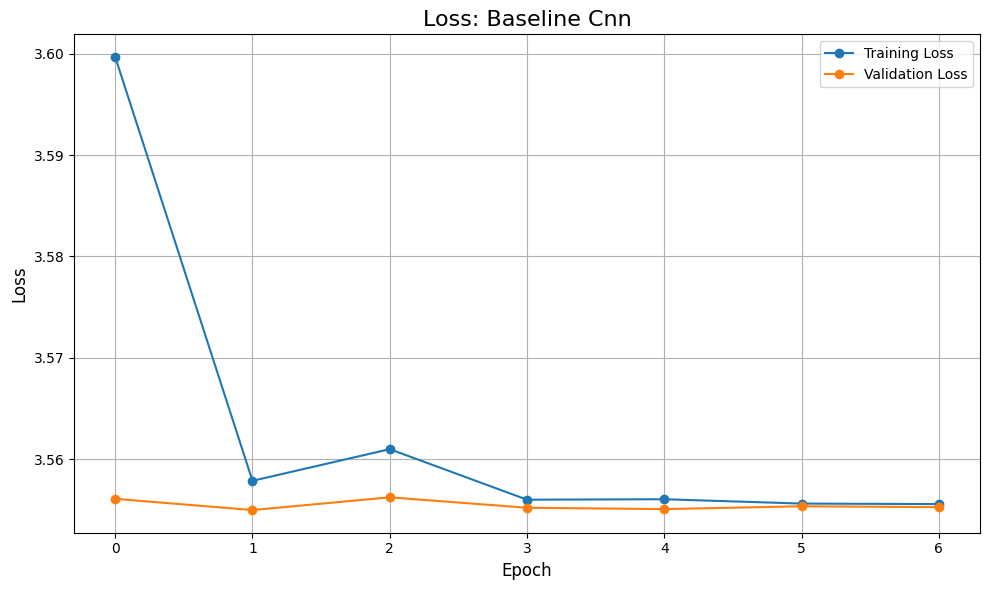

Loss plot saved to /kaggle/working/baseline_cnn/baseline_cnn_loss.png


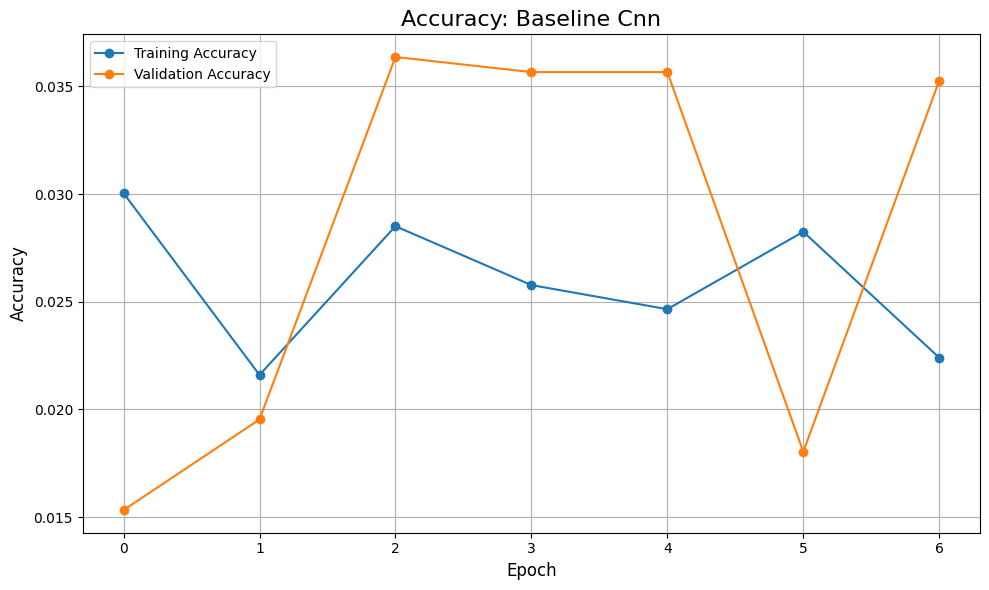

Accuracy plot saved to /kaggle/working/baseline_cnn/baseline_cnn_accuracy.png
Training history saved to /kaggle/working/baseline_cnn/training_history.pkl
Metadata saved to /kaggle/working/baseline_cnn/metadata_baseline_cnn.json


In [16]:
save_and_plot_results(history, model, model_name, saving_dir)

## Residual CNN

In [17]:
class ResidualCNN:
    def __init__(self, input_shape=(40, 101, 1), num_classes=len(label_to_index)):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()

    def _res_block(self, x, filters, stride=1):
        shortcut = x

        # First convolutional layer
        x = layers.Conv2D(filters, kernel_size=3, strides=stride, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        # Second convolutional layer
        x = layers.Conv2D(filters, kernel_size=3, strides=1, padding='same')(x)
        x = layers.BatchNormalization()(x)

        # Shortcut connection
        if stride != 1 or shortcut.shape[-1] != filters:
            shortcut = layers.Conv2D(filters, kernel_size=1, strides=stride, padding='same')(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)

        x = layers.add([x, shortcut])
        x = layers.ReLU()(x)
        return x

    def _build_model(self):
        inputs = layers.Input(shape=self.input_shape)

        x = layers.Conv2D(32, kernel_size=3, strides=1, padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        # Residual blocks
        x = self._res_block(x, 32)
        x = self._res_block(x, 64, stride=2)
        x = self._res_block(x, 128, stride=2)

        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(0.3)(x)
        outputs = layers.Dense(self.num_classes, activation='softmax')(x)

        model = models.Model(inputs, outputs)
        return model

    def compile(self, optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    def get_model(self):
        return self.model

In [18]:
residual_cnn = ResidualCNN(input_shape=(40, 101, 1), num_classes=len(label_to_index))

model_name = "residual_cnn"
saving_dir = f"{OUTPUT_DATA_DIR}/{model_name}"
os.makedirs(saving_dir, exist_ok=True)

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1)

checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(saving_dir, f"{model_name}_best.keras"),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max')

lr_scheduler_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1)

residual_cnn.compile()

model = residual_cnn.get_model()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping_cb, checkpoint_cb, lr_scheduler_cb]
)

Epoch 1/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 52s 27ms/step - accuracy: 0.2814 - loss: 2.6500 - val_accuracy: 0.7317 - val_loss: 0.9587 - learning_rate: 0.0010
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.7641 - loss: 0.8675 - val_accuracy: 0.8527 - val_loss: 0.5081 - learning_rate: 0.0010
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.8270 - loss: 0.6166 - val_accuracy: 0.8814 - val_loss: 0.3827 - learning_rate: 0.0010
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.8582 - loss: 0.5005 - val_accuracy: 0.8783 - val_loss: 0.4150 - learning_rate: 0.0010
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.8738 - loss: 0.4373 - val_accuracy: 0.9237 - val_loss: 0.2637 - learning_rate: 0.0010
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.8883 - loss: 0.3866 - val_accuracy: 0.9106 - val_loss: 0.2977 - learning_rate: 0.0010
Epoch 7/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accura

In [19]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 40, 101,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 40, 101,   │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 101,   │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 40, 101,   │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 101,   │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 40, 101,   │      9,248 │ re_lu_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 101,   │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 40, 101,   │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 20, 51,    │     18,496 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 51,    │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 20, 51,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 20, 51,    │     36,928 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 20, 51,    │      2,112 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 51,    │        256 │ conv2d_6[0][0]  

 Total params: 937,259 (3.58 MB)

 Trainable params: 311,971 (1.19 MB)

 Non-trainable params: 1,344 (5.25 KB)

 Optimizer params: 623,944 (2.38 MB)

In [20]:
val_loss, val_acc = model.evaluate(val_ds)

test_loss, test_acc = model.evaluate(test_ds)

print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9557 - loss: 0.1666
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9597 - loss: 0.1409

Validation accuracy: 0.9562
Validation loss: 0.1538

Test accuracy: 0.9531
Test loss: 0.1628



--- Saving results for model: residual_cnn ---


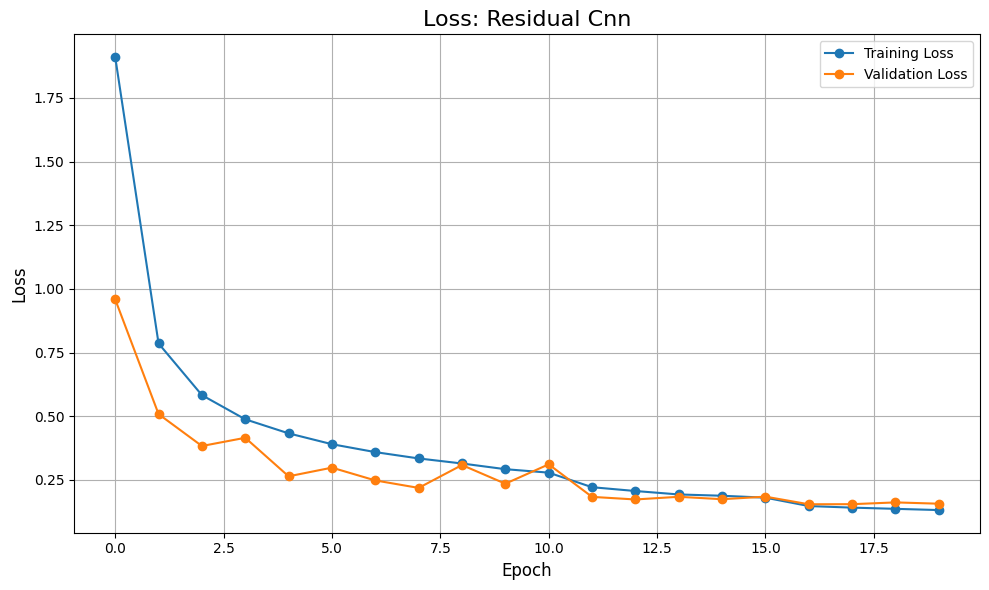

Loss plot saved to /kaggle/working/residual_cnn/residual_cnn_loss.png


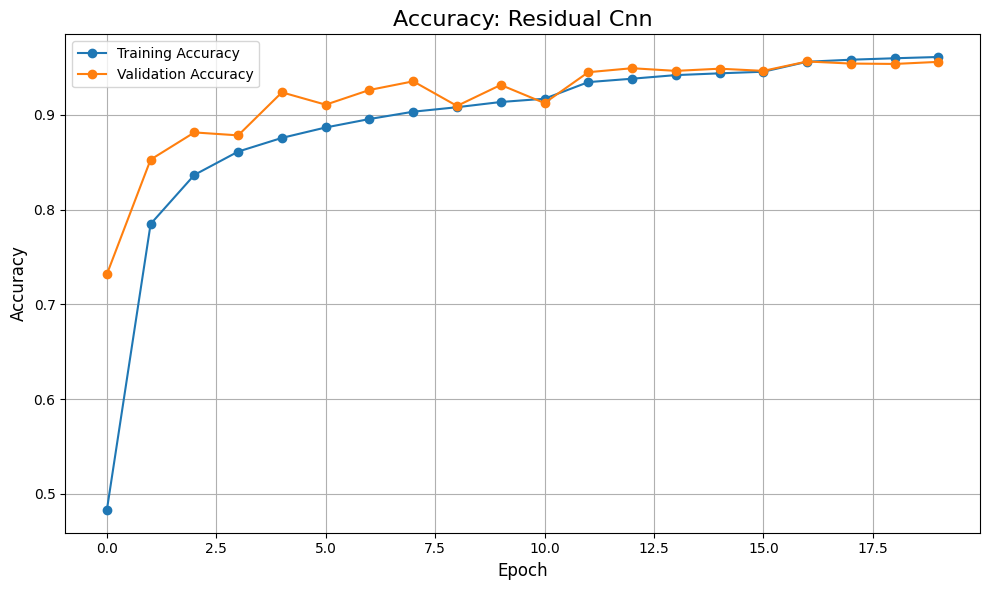

Accuracy plot saved to /kaggle/working/residual_cnn/residual_cnn_accuracy.png
Training history saved to /kaggle/working/residual_cnn/training_history.pkl
Metadata saved to /kaggle/working/residual_cnn/metadata_residual_cnn.json


In [21]:
save_and_plot_results(history, model, model_name, saving_dir)

## CNN + BiLSTM

In [22]:
class CNNBiLSTMModel:
    def __init__(self, input_shape=(40, 101, 1), num_classes=12,
                 lstm_units=32, dense_units=64, dropout_rate=0.3):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.lstm_units = lstm_units
        self.dense_units = dense_units
        self.dropout_rate = dropout_rate
        self.model = self._build_model()

    def _build_model(self):
        inputs = tf.keras.Input(shape=self.input_shape)

        # CNN Layers
        x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(pool_size=(2, 2))(x)

        x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(pool_size=(2, 2))(x)

        # Reshape
        x = layers.Reshape((10, 800))(x)

        # Feature Compression
        x = layers.TimeDistributed(layers.Dense(64, activation='relu'))(x)

        # BiLSTM with return_sequences
        x = layers.Bidirectional(
            layers.LSTM(self.lstm_units, return_sequences=True)
        )(x)

        # Pooling across time
        x = layers.GlobalAveragePooling1D()(x)

        # Dropout + Classifier
        x = layers.Dropout(self.dropout_rate)(x)
        x = layers.Dense(self.dense_units, activation='relu')(x)
        x = layers.Dropout(self.dropout_rate / 1.5)(x)
        outputs = layers.Dense(self.num_classes, activation='softmax')(x)

        return models.Model(inputs, outputs)

    def compile(self, learning_rate=0.001):
        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

    def get_model(self):
        return self.model

In [23]:
cnn_bilstm = CNNBiLSTMModel(input_shape=(40, 101, 1), num_classes=len(label_to_index))

model_name = "cnn_bilstm"
saving_dir = f"{OUTPUT_DATA_DIR}/{model_name}"
os.makedirs(saving_dir, exist_ok=True)

cnn_bilstm.compile()

model = cnn_bilstm.get_model()

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1)

checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(saving_dir, f"{model_name}_best.keras"),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max')

lr_scheduler_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping_cb, checkpoint_cb, lr_scheduler_cb]
)

Epoch 1/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.0944 - loss: 3.2730 - val_accuracy: 0.4085 - val_loss: 2.0162 - learning_rate: 0.0010
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.4067 - loss: 2.0044 - val_accuracy: 0.6971 - val_loss: 1.0563 - learning_rate: 0.0010
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.5745 - loss: 1.4162 - val_accuracy: 0.7474 - val_loss: 0.8468 - learning_rate: 0.0010
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.6512 - loss: 1.1461 - val_accuracy: 0.7888 - val_loss: 0.6968 - learning_rate: 0.0010
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.6912 - loss: 1.0038 - val_accuracy: 0.7949 - val_loss: 0.6841 - learning_rate: 0.0010
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.7208 - loss: 0.9047 - val_accuracy: 0.8190 - val_loss: 0.5969 - learning_rate: 0.0010
Epoch 7/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accura

In [24]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 40, 101, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 40, 101, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 40, 101, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 20, 50, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 20, 50, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 10, 800)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 64)         │        51,264 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 10, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 262,379 (1.00 MB)

 Trainable params: 87,427 (341.51 KB)

 Non-trainable params: 96 (384.00 B)

 Optimizer params: 174,856 (683.04 KB)

In [25]:
val_loss, val_acc = model.evaluate(val_ds)

test_loss, test_acc = model.evaluate(test_ds)

print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8559 - loss: 0.4910
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8505 - loss: 0.4969

Validation accuracy: 0.8641
Validation loss: 0.4568

Test accuracy: 0.8556
Test loss: 0.5055



--- Saving results for model: cnn_bilstm ---


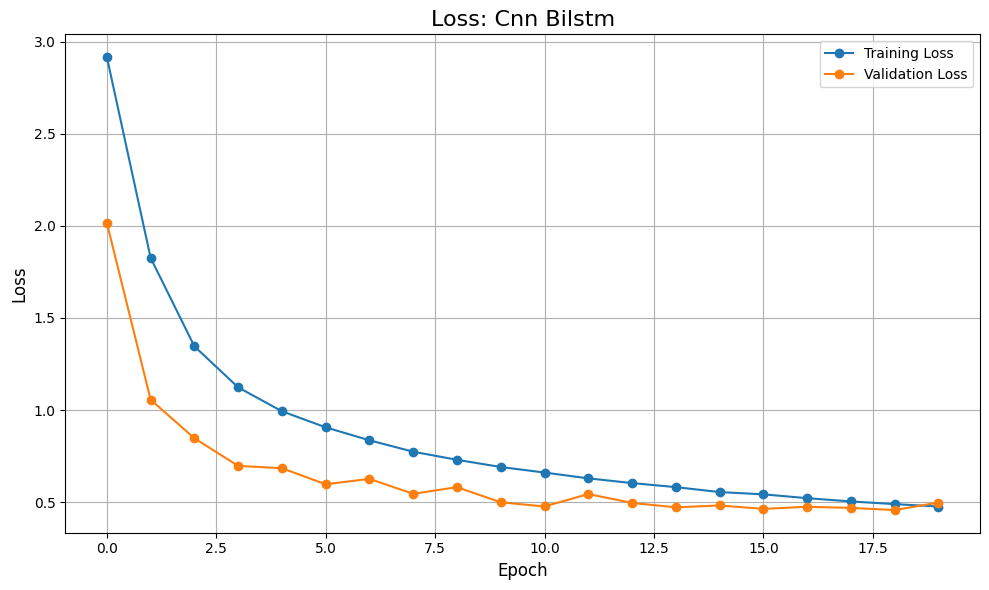

Loss plot saved to /kaggle/working/cnn_bilstm/cnn_bilstm_loss.png


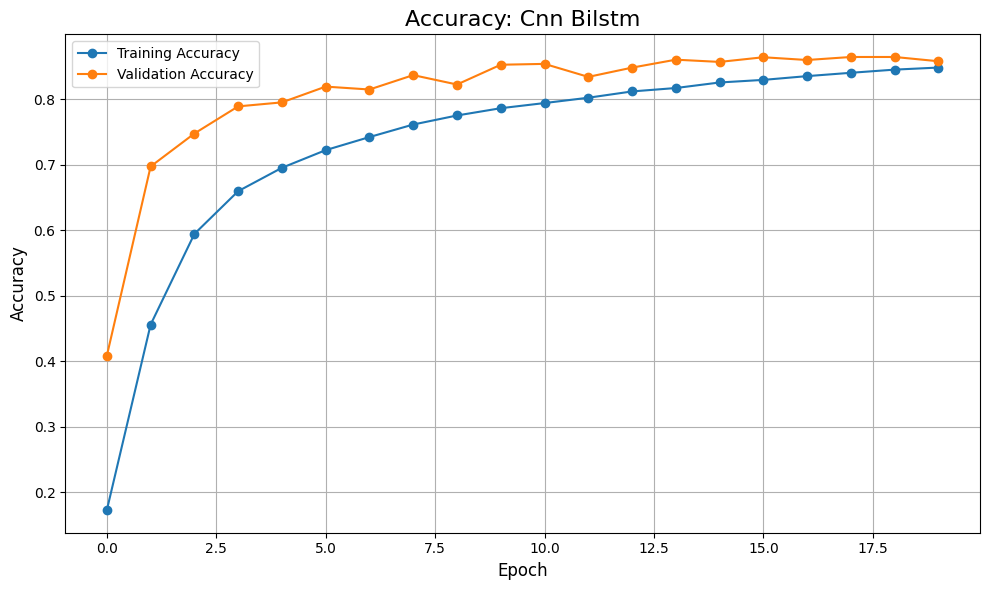

Accuracy plot saved to /kaggle/working/cnn_bilstm/cnn_bilstm_accuracy.png
Training history saved to /kaggle/working/cnn_bilstm/training_history.pkl
Metadata saved to /kaggle/working/cnn_bilstm/metadata_cnn_bilstm.json


In [26]:
save_and_plot_results(history, model, model_name, saving_dir)

# Transformer Models

In [27]:
def transformer_encoder_block(embed_dim, num_heads, ff_dim, dropout_rate=0.1):
    inputs = layers.Input(shape=(None, embed_dim))
    
    # Multi-Head Attention
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim
    )(inputs, inputs)
    attention_output = layers.Dropout(dropout_rate)(attention_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(inputs + attention_output)

    # Feed-Forward Network
    ffn_output = layers.Dense(ff_dim, activation="relu")(out1)
    ffn_output = layers.Dense(embed_dim)(ffn_output)
    ffn_output = layers.Dropout(dropout_rate)(ffn_output)
    out2 = layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)
    
    return models.Model(inputs=inputs, outputs=out2)

@register_keras_serializable()
class PositionalEncoding(layers.Layer):
    def __init__(self, max_steps, max_dims, **kwargs):
        super().__init__(**kwargs)
        self.max_steps = max_steps
        self.max_dims = max_dims
        self.positional_encoding = self.build_pe(max_steps, max_dims)

    def build_pe(self, max_steps, max_dims):
        pe = np.zeros((max_steps, max_dims))
        position = np.arange(0, max_steps, dtype=np.float32).reshape(-1, 1)
        div_term = np.exp(np.arange(0, max_dims, 2, dtype=np.float32) * -(np.log(10000.0) / max_dims))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        return tf.constant(pe, dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.positional_encoding

    def get_config(self):
        config = super().get_config()
        config.update({
            "max_steps": self.max_steps,
            "max_dims": self.max_dims,
        })
        return config

## CNN - Hybrid Transformer

In [28]:
class HybridCNNTransformerModel:
    def __init__(self, input_shape=(40, 101, 1), num_classes=len(label_to_index),
                 num_transformer_blocks=2, embed_dim=64, num_heads=4, ff_dim=64, dropout_rate=0.2):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.num_transformer_blocks = num_transformer_blocks
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        self.model = self._build_model()

    def _build_model(self):
        inputs = layers.Input(shape=self.input_shape)

        # Convolutional Feature Extractor
        x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)

        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x) # --> Output shape: (None, 10, 25, 64)

        # 2. Reshape to a sequence
        # Prima, trasponiamo per portare l'asse del tempo (width) come dimensione della sequenza
        x = layers.Permute((2, 1, 3))(x) # --> Output shape: (None, 25, 10, 64)

        # Ora, appiattiamo le ultime due dimensioni (frequenza e canali)
        # Non serve tf.shape, il layer Reshape può inferire le dimensioni
        # La target_shape non include la dimensione del batch
        x = layers.Reshape((x.shape[1], -1))(x) # --> Output shape: (None, 25, 640)
        
        # Project to the Transformer's embedding dimension
        x = layers.Dense(self.embed_dim)(x)
        
        # Add Positional Encoding
        x = PositionalEncoding(max_steps=x.shape[1], max_dims=self.embed_dim)(x)

        # Transformer Encoder Blocks
        for _ in range(self.num_transformer_blocks):
            encoder = transformer_encoder_block(self.embed_dim, self.num_heads, self.ff_dim, self.dropout_rate)
            x = encoder(x)
        
        # Classifier Head
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dropout(self.dropout_rate)(x)
        x = layers.Dense(self.ff_dim, activation='relu')(x)
        x = layers.Dropout(self.dropout_rate)(x)
        outputs = layers.Dense(self.num_classes, activation='softmax')(x)

        return models.Model(inputs=inputs, outputs=outputs)

    def compile(self, optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    def get_model(self):
        return self.model

In [29]:
hybrid_cnn_transformer = HybridCNNTransformerModel(input_shape=(40, 101, 1), num_classes=len(label_to_index))

model_name = "hybrid_cnn_transformer"
saving_dir = f"{OUTPUT_DATA_DIR}/{model_name}"
os.makedirs(saving_dir, exist_ok=True)

hybrid_cnn_transformer.compile()

model = hybrid_cnn_transformer.get_model()

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1)

checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(saving_dir, f"{model_name}_best.keras"),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max')

lr_scheduler_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping_cb, checkpoint_cb, lr_scheduler_cb]
)

Epoch 1/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 39s 16ms/step - accuracy: 0.3074 - loss: 2.4463 - val_accuracy: 0.8138 - val_loss: 0.6392 - learning_rate: 0.0010
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7390 - loss: 0.8980 - val_accuracy: 0.8480 - val_loss: 0.5055 - learning_rate: 0.0010
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.8062 - loss: 0.6865 - val_accuracy: 0.8769 - val_loss: 0.4196 - learning_rate: 0.0010
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.8162 - loss: 0.6428 - val_accuracy: 0.8945 - val_loss: 0.3502 - learning_rate: 0.0010
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.8349 - loss: 0.5796 - val_accuracy: 0.8778 - val_loss: 0.4102 - learning_rate: 0.0010
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.8430 - loss: 0.5535 - val_accuracy: 0.8610 - val_loss: 0.4699 - learning_rate: 0.0010
Epoch 7/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.

In [30]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 40, 101, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 40, 101, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 40, 101, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 20, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 20, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 20, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 25, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 25, 640)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 25, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 25, 64)         │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_3 (Functional)       │ (None, 25, 64)         │        74,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_4 (Functional)       │ (None, 25, 64)         │        74,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649,259 (2.48 MB)

 Trainable params: 216,355 (845.14 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 432,712 (1.65 MB)

In [31]:
val_loss, val_acc = model.evaluate(val_ds)

test_loss, test_acc = model.evaluate(test_ds)

print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9403 - loss: 0.2271
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9343 - loss: 0.2275

Validation accuracy: 0.9442
Validation loss: 0.1996

Test accuracy: 0.9378
Test loss: 0.2148



--- Saving results for model: hybrid_cnn_transformer ---


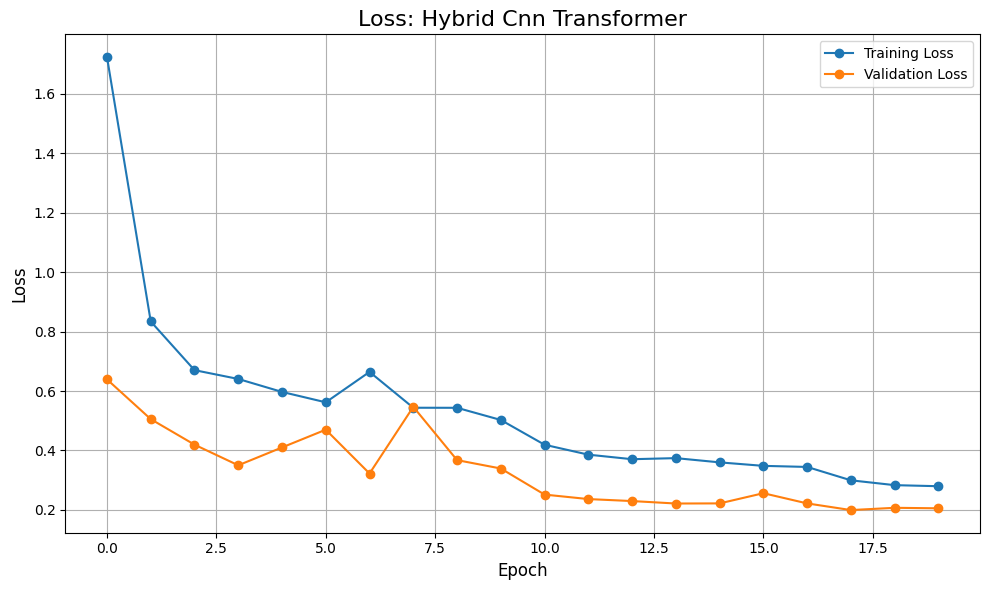

Loss plot saved to /kaggle/working/hybrid_cnn_transformer/hybrid_cnn_transformer_loss.png


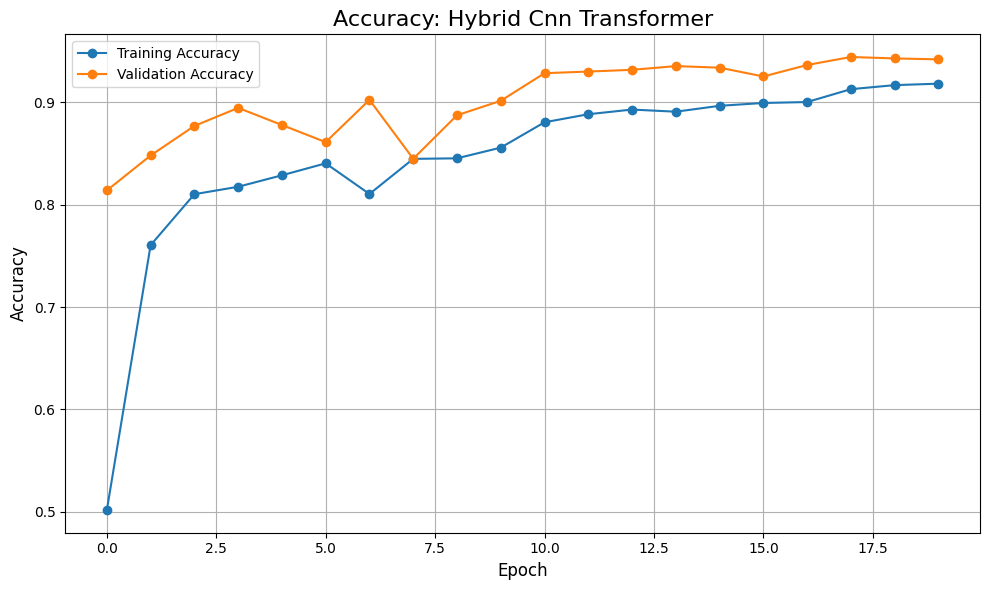

Accuracy plot saved to /kaggle/working/hybrid_cnn_transformer/hybrid_cnn_transformer_accuracy.png
Training history saved to /kaggle/working/hybrid_cnn_transformer/training_history.pkl
Metadata saved to /kaggle/working/hybrid_cnn_transformer/metadata_hybrid_cnn_transformer.json


In [32]:
save_and_plot_results(history, model, model_name, saving_dir)

## Vision Transformer

In [33]:
@register_keras_serializable()
class Patches(layers.Layer):
    """Splits an image into patches."""
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches
    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config
    

@register_keras_serializable()
class PatchEncoder(layers.Layer):
    """Encodes patches with a projection and positional embedding."""
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.embed_dim = embed_dim
        
    def build(self, input_shape):
        self.projection = layers.Dense(units=self.embed_dim)
        self.positional_embedding = layers.Embedding(
            input_dim=self.num_patches, output_dim=self.embed_dim
        )
        super().build(input_shape)

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.positional_embedding(positions)
        return encoded
        
    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "embed_dim": self.embed_dim,
        })
        return config

In [34]:
class VisionTransformerModel:
    def __init__(self, input_shape=(40, 101, 1), num_classes=len(label_to_index),
                 patch_size=8, num_transformer_blocks=2, embed_dim=64, 
                 num_heads=4, ff_dim=64, dropout_rate=0.2):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.patch_size = patch_size
        self.num_transformer_blocks = num_transformer_blocks
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        self.model = self._build_model()

    def _build_model(self):
        inputs = layers.Input(shape=self.input_shape)
        
        # Since the input dimensions (40, 101) are not perfectly divisible by patch_size,
        # we first resize to a divisible dimension, e.g., (40, 104) -> divisible by 8
        # Note: 101 is prime, so padding/resizing is needed. 104 is a good choice.
        resized_input = layers.Resizing(height=40, width=104)(inputs)
        
        # Create Patches
        num_patches = (40 // self.patch_size) * (104 // self.patch_size)
        patches = Patches(self.patch_size)(resized_input)

        # Encode Patches with positional embedding
        encoded_patches = PatchEncoder(num_patches, self.embed_dim)(patches)

        # Transformer Encoder Blocks
        x = encoded_patches
        for _ in range(self.num_transformer_blocks):
            encoder = transformer_encoder_block(self.embed_dim, self.num_heads, self.ff_dim, self.dropout_rate)
            x = encoder(x)
            
        # Classifier Head
        # Global average pooling over the sequence of patches
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dropout(self.dropout_rate)(x)
        outputs = layers.Dense(self.num_classes, activation="softmax")(x)

        return models.Model(inputs=inputs, outputs=outputs)
    
    def compile(self, optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    def get_model(self):
        return self.model

In [35]:
vision_transformer = VisionTransformerModel(input_shape=(40, 101, 1), num_classes=len(label_to_index))

model_name = "vision_transformer"
saving_dir = f"{OUTPUT_DATA_DIR}/{model_name}"
os.makedirs(saving_dir, exist_ok=True)

vision_transformer.compile()

model = vision_transformer.get_model()

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1)

checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(saving_dir, f"{model_name}_best.keras"),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max')

lr_scheduler_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping_cb, checkpoint_cb, lr_scheduler_cb]
)

Epoch 1/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - accuracy: 0.1248 - loss: 3.1948 - val_accuracy: 0.5372 - val_loss: 1.5699 - learning_rate: 0.0010
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4739 - loss: 1.8561 - val_accuracy: 0.6558 - val_loss: 1.1265 - learning_rate: 0.0010
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5834 - loss: 1.4447 - val_accuracy: 0.7336 - val_loss: 0.8843 - learning_rate: 0.0010
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6375 - loss: 1.2611 - val_accuracy: 0.7490 - val_loss: 0.8198 - learning_rate: 0.0010
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6615 - loss: 1.1561 - val_accuracy: 0.7837 - val_loss: 0.7088 - learning_rate: 0.0010
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6859 - loss: 1.0687 - val_accuracy: 0.7922 - val_loss: 0.6773 - learning_rate: 0.0010
Epoch 7/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7059 -

In [36]:
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 40, 101, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 40, 104, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patches (Patches)               │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_encoder (PatchEncoder)    │ (None, 65, 64)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_6 (Functional)       │ (None, 65, 64)         │        74,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_7 (Functional)       │ (None, 65, 64)         │        74,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481,451 (1.84 MB)

 Trainable params: 160,483 (626.89 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 320,968 (1.22 MB)

In [37]:
val_loss, val_acc = model.evaluate(val_ds)

test_loss, test_acc = model.evaluate(test_ds)

print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8690 - loss: 0.4607
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8467 - loss: 0.5094

Validation accuracy: 0.8653
Validation loss: 0.4502

Test accuracy: 0.8504
Test loss: 0.5074



--- Saving results for model: vision_transformer ---


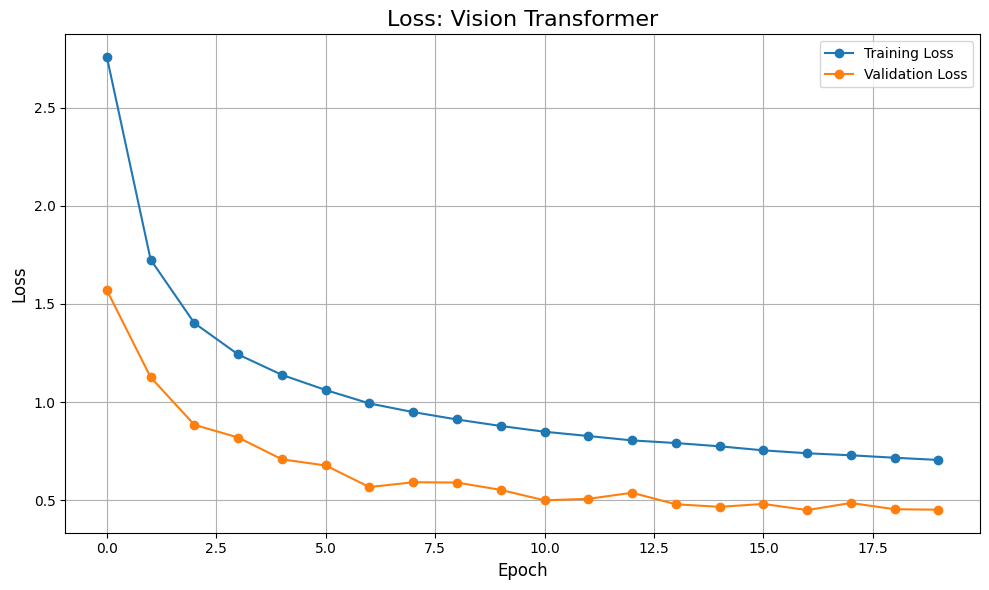

Loss plot saved to /kaggle/working/vision_transformer/vision_transformer_loss.png


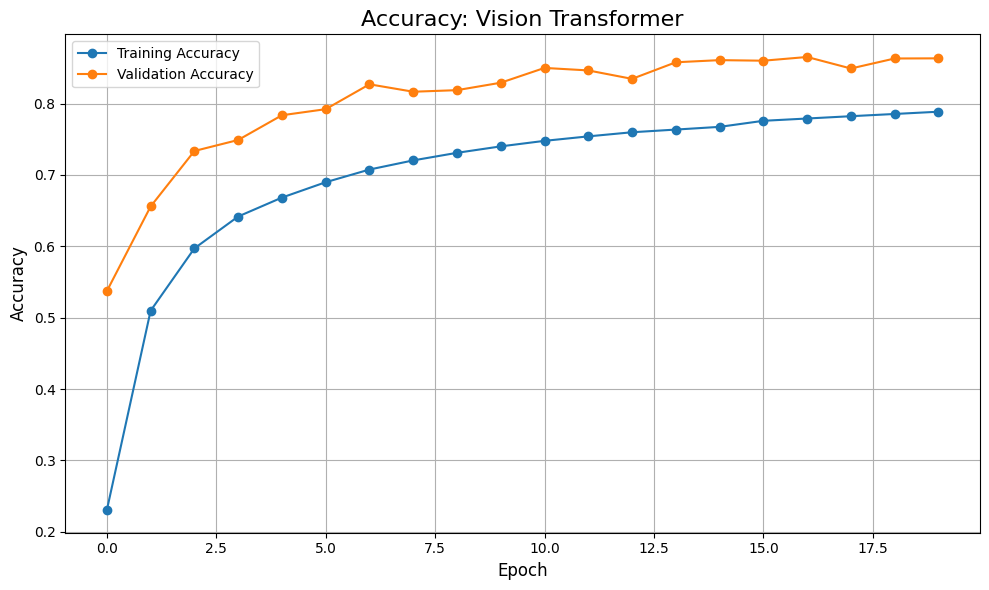

Accuracy plot saved to /kaggle/working/vision_transformer/vision_transformer_accuracy.png
Training history saved to /kaggle/working/vision_transformer/training_history.pkl
Metadata saved to /kaggle/working/vision_transformer/metadata_vision_transformer.json


In [38]:
save_and_plot_results(history, model, model_name, saving_dir)

# Experimental models

### Dynamic Tanh (DyT)

In [39]:
# @register_keras_serializable()
# class DyT(layers.Layer):
#     """
#     Implements the Dynamic Tanh (DyT) as described in the paper
#     "Transformers without Normalization".
#     DyT(x) = gamma * tanh(alpha * x) + beta
#     """
#     def __init__(self, embed_dim, init_a=0.5, **kwargs):
#         super().__init__(**kwargs)
#         self.init_a = init_a
#         self.embed_dim = embed_dim

#     def build(self, input_shape):
#         # Alpha
#         self.alpha = self.add_weight(
#             name='alpha',
#             shape=(1,),
#             initializer=tf.keras.initializers.Constant(value=self.init_a),
#             trainable=True
#         )
#         # Gamma
#         self.gamma = self.add_weight(
#             name='gamma',
#             shape=(self.embed_dim,),
#             initializer='ones',
#             trainable=True
#         )
#         # Beta
#         self.beta = self.add_weight(
#             name='beta',
#             shape=(self.embed_dim,),
#             initializer='zeros',
#             trainable=True
#         )
#         super().build(input_shape)

#     def call(self, x):
#         return self.gamma * tf.tanh(self.alpha * x) + self.beta

#     def get_config(self):
#         config = super().get_config()
#         config.update({
#             "embed_dim": self.embed_dim,
#             "init_a": self.init_a,
#         })
#         return config

In [40]:
# def transformer_encoder_block_dyt(embed_dim, num_heads, ff_dim, dropout_rate=0.1):
#     inputs = layers.Input(shape=(None, embed_dim))
    
#     # Multi-Head Attention
#     attention_output = layers.MultiHeadAttention(
#         num_heads=num_heads, key_dim=embed_dim
#     )(inputs, inputs)
#     attention_output = layers.Dropout(dropout_rate)(attention_output)

#     # DyT instead of LayerNormalization
#     out1 = DyT(embed_dim=embed_dim, init_a=0.5)(inputs + attention_output)

#     # Feed-Forward Network
#     ffn_output = layers.Dense(ff_dim, activation="relu")(out1)
#     ffn_output = layers.Dense(embed_dim)(ffn_output)
#     ffn_output = layers.Dropout(dropout_rate)(ffn_output)

#     # DyT instead of LayerNormalization
#     out2 = DyT(embed_dim=embed_dim, init_a=0.5)(out1 + ffn_output)
    
#     return models.Model(inputs=inputs, outputs=out2)

In [41]:
# class HybridCNNTransformerModelDyT:
#     def __init__(self, input_shape=(40, 101, 1), num_classes=len(label_to_index),
#                  num_transformer_blocks=2, embed_dim=64, num_heads=4, ff_dim=64, dropout_rate=0.2):
#         self.input_shape = input_shape
#         self.num_classes = num_classes
#         self.num_transformer_blocks = num_transformer_blocks
#         self.embed_dim = embed_dim
#         self.num_heads = num_heads
#         self.ff_dim = ff_dim
#         self.dropout_rate = dropout_rate
#         self.model = self._build_model()

#     def _build_model(self):
#         inputs = layers.Input(shape=self.input_shape)

#         # Convolutional Feature Extractor
#         x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
#         x = layers.BatchNormalization()(x)
#         x = layers.MaxPooling2D((2, 2))(x)

#         x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
#         x = layers.BatchNormalization()(x)
#         x = layers.MaxPooling2D((2, 2))(x) # --> Output shape: (None, 10, 25, 64)

#         # 2. Reshape to a sequence
#         # Prima, trasponiamo per portare l'asse del tempo (width) come dimensione della sequenza
#         x = layers.Permute((2, 1, 3))(x) # --> Output shape: (None, 25, 10, 64)

#         # Ora, appiattiamo le ultime due dimensioni (frequenza e canali)
#         # Non serve tf.shape, il layer Reshape può inferire le dimensioni
#         # La target_shape non include la dimensione del batch
#         x = layers.Reshape((x.shape[1], -1))(x) # --> Output shape: (None, 25, 640)
        
#         # Project to the Transformer's embedding dimension
#         x = layers.Dense(self.embed_dim)(x)
        
#         # Add Positional Encoding
#         x = PositionalEncoding(max_steps=x.shape[1], max_dims=self.embed_dim)(x)

#         # Transformer Encoder Blocks
#         for _ in range(self.num_transformer_blocks):
#             encoder = transformer_encoder_block_dyt(self.embed_dim, self.num_heads, self.ff_dim, self.dropout_rate)
#             x = encoder(x)
        
#         # Classifier Head
#         x = layers.GlobalAveragePooling1D()(x)
#         x = layers.Dropout(self.dropout_rate)(x)
#         x = layers.Dense(self.ff_dim, activation='relu')(x)
#         x = layers.Dropout(self.dropout_rate)(x)
#         outputs = layers.Dense(self.num_classes, activation='softmax')(x)

#         return models.Model(inputs=inputs, outputs=outputs)

#     def compile(self, optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']):
#         self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

#     def get_model(self):
#         return self.model

In [42]:
# class VisionTransformerModelDyT:
#     def __init__(self, input_shape=(40, 101, 1), num_classes=len(label_to_index),
#                  patch_size=8, num_transformer_blocks=2, embed_dim=64, 
#                  num_heads=4, ff_dim=64, dropout_rate=0.2):
#         self.input_shape = input_shape
#         self.num_classes = num_classes
#         self.patch_size = patch_size
#         self.num_transformer_blocks = num_transformer_blocks
#         self.embed_dim = embed_dim
#         self.num_heads = num_heads
#         self.ff_dim = ff_dim
#         self.dropout_rate = dropout_rate
#         self.model = self._build_model()

#     def _build_model(self):
#         inputs = layers.Input(shape=self.input_shape)
        
#         # Since the input dimensions (40, 101) are not perfectly divisible by patch_size,
#         # we first resize to a divisible dimension, e.g., (40, 104) -> divisible by 8
#         # Note: 101 is prime, so padding/resizing is needed. 104 is a good choice.
#         resized_input = layers.Resizing(height=40, width=104)(inputs)
        
#         # Create Patches
#         num_patches = (40 // self.patch_size) * (104 // self.patch_size)
#         patches = Patches(self.patch_size)(resized_input)

#         # Encode Patches with positional embedding
#         encoded_patches = PatchEncoder(num_patches, self.embed_dim)(patches)

#         # Transformer Encoder Blocks
#         x = encoded_patches
#         for _ in range(self.num_transformer_blocks):
#             encoder = transformer_encoder_block_dyt(self.embed_dim, self.num_heads, self.ff_dim, self.dropout_rate)
#             x = encoder(x)
            
#         # Classifier Head
#         # Global average pooling over the sequence of patches
#         x = layers.GlobalAveragePooling1D()(x)
#         x = layers.Dropout(self.dropout_rate)(x)
#         outputs = layers.Dense(self.num_classes, activation="softmax")(x)

#         return models.Model(inputs=inputs, outputs=outputs)
    
#     def compile(self, optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']):
#         self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

#     def get_model(self):
#         return self.model

## Axial Attention Transformer

In [43]:
class AxialAttentionModel:
    def __init__(self, input_shape=(40, 101, 1), num_classes=len(label_to_index),
                 num_axial_blocks=2, embed_dim=64, num_heads=4, ff_dim=64, dropout_rate=0.2):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.num_axial_blocks = num_axial_blocks
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        self.model = self._build_model()
    
    def _axial_attention_block(self, inputs):
        """Applies attention first across frequency axis, then across time axis."""
        
        # Input shape: (batch, freq, time, channels) e.g., (None, 40, 101, 64)
        
        # --- Frequency Attention ---
        # We want to apply attention across the 40 frequency bins for each of the 101 time steps.
        # Permute to make 'time' the axis for TimeDistributed: (batch, time, freq, channels)
        x = layers.Permute((2, 1, 3))(inputs) # Shape -> (None, 101, 40, 64)
        
        # The TimeDistributed layer will now iterate over the 101 time steps,
        # applying the encoder to each slice of shape (None, 40, 64).
        freq_encoder = transformer_encoder_block(self.embed_dim, self.num_heads, self.ff_dim, self.dropout_rate)
        x = layers.TimeDistributed(freq_encoder)(x)
        
        # Permute back to original format: (batch, freq, time, channels)
        x = layers.Permute((2, 1, 3))(x) # Shape -> (None, 40, 101, 64)
        
        # Add residual connection
        x = layers.Add()([inputs, x])
        residual_out = x # This will be the input for the next residual connection

        # --- Time Attention ---
        # Now we want to apply attention across the 101 time steps for each of the 40 frequency bins.
        # The input shape is already (batch, freq, time, channels).
        # TimeDistributed will iterate over the 40 frequency bins.
        time_encoder = transformer_encoder_block(self.embed_dim, self.num_heads, self.ff_dim, self.dropout_rate)
        x = layers.TimeDistributed(time_encoder)(x)

        # Add residual connection
        x = layers.Add()([residual_out, x])

        return x

    def _build_model(self):
        inputs = layers.Input(shape=self.input_shape)

        # Initial Convolutional Stem to project to embed_dim
        x = layers.Conv2D(self.embed_dim, kernel_size=1, padding="same")(inputs)
        x = layers.BatchNormalization()(x)

        # Axial Attention Blocks
        for _ in range(self.num_axial_blocks):
            x = self._axial_attention_block(x)

        # Classifier Head
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(self.dropout_rate)(x)
        outputs = layers.Dense(self.num_classes, activation="softmax")(x)

        return models.Model(inputs=inputs, outputs=outputs)

    def compile(self, optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    def get_model(self):
        return self.model

In [44]:
# axial_attention_model = AxialAttentionModel(
#     input_shape=(40, 101, 1),
#     num_classes=len(label_to_index),
#     num_axial_blocks=1,  # Inizia con un solo blocco
#     embed_dim=32,        # Riduci la dimensione
#     num_heads=2,         # Riduci il numero di teste
#     ff_dim=32,           # Riduci la dimensione del feed-forward
#     dropout_rate=0.2
# )

# model_name = "axial_attention_model"
# saving_dir = f"{OUTPUT_DATA_DIR}/{model_name}"
# os.makedirs(saving_dir, exist_ok=True)

# axial_attention_model.compile()

# model = axial_attention_model.get_model()

# early_stopping_cb = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#     patience=5,
#     restore_best_weights=True,
#     verbose=1)

# checkpoint_cb = ModelCheckpoint(
#     filepath=os.path.join(saving_dir, f"{model_name}_best.keras"),
#     monitor='val_accuracy',
#     save_best_only=True,
#     mode='max')

# lr_scheduler_cb = ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.5,
#     patience=3,
#     min_lr=1e-6,
#     verbose=1)

# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=20,
#     class_weight=class_weights,
#     callbacks=[early_stopping_cb, checkpoint_cb, lr_scheduler_cb]
# )

In [45]:
# model.summary()

In [46]:
# val_loss, val_acc = model.evaluate(val_ds)

# test_loss, test_acc = model.evaluate(test_ds)

# print(f"\nValidation accuracy: {val_acc:.4f}")
# print(f"Validation loss: {val_loss:.4f}")

# print(f"\nTest accuracy: {test_acc:.4f}")
# print(f"Test loss: {test_loss:.4f}")

In [47]:
# save_and_plot_results(history, model, model_name, saving_dir)

## GAN

Residual CNN as feature extractor + a GAN-style discriminator as classifier (more experimental but I think it could be interesting!)


In [48]:
class ResidualGANInspiredClassifier:
    def __init__(self, input_shape=(40, 101, 1), num_classes=label_to_index,
                 dropout_rate=0.4):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.dropout_rate = dropout_rate
        self.model = self._build_model()

    def _res_block(self, x, filters, stride=1):
        """ Same residual block as the Residual CNN Model"""
        shortcut = x
        x = layers.Conv2D(filters, kernel_size=3, strides=stride, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, kernel_size=3, strides=1, padding='same')(x)
        x = layers.BatchNormalization()(x)
        if stride != 1 or shortcut.shape[-1] != filters:
            shortcut = layers.Conv2D(filters, kernel_size=1, strides=stride, padding='same')(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)
        x = layers.add([x, shortcut])
        x = layers.ReLU()(x)
        return x

    def _build_model(self):
        inputs = layers.Input(shape=self.input_shape)

        # --- Part 1: Feature Extractor (based on Residual CNN) ---
        # This part extracts high-level features from the spectrogram.
        x = layers.Conv2D(32, kernel_size=3, strides=1, padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        
        x = self._res_block(x, 32)
        x = self._res_block(x, 64, stride=2)
        feature_map = self._res_block(x, 128, stride=2) # Output: (10, 26, 128)

        # --- Part 2: Discriminator-style Classifier ---
        # This part takes the feature map and classifies it, using GAN-like architectural choices.
        
        l2_rate = 1e-4

        x = layers.Conv2D(128, kernel_size=3, strides=2, padding='same',
                          kernel_regularizer=regularizers.l2(l2_rate))(feature_map)
        x = layers.LeakyReLU(alpha=0.2)(x)
        x = layers.Dropout(self.dropout_rate)(x)

        x = layers.Conv2D(256, kernel_size=3, strides=2, padding='same',
                          kernel_regularizer=regularizers.l2(l2_rate))(x)
        x = layers.LeakyReLU(alpha=0.2)(x)
        x = layers.Dropout(self.dropout_rate)(x)

        x = layers.GlobalAveragePooling2D()(x)
        
        outputs = layers.Dense(self.num_classes, activation='softmax',
                               kernel_regularizer=regularizers.l2(l2_rate))(x)

        return models.Model(inputs=inputs, outputs=outputs)

    def compile(self, optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    def get_model(self):
        return self.model

In [49]:
residual_gan_classifier = ResidualGANInspiredClassifier(input_shape=(40, 101, 1), num_classes=len(label_to_index))

model_name = "residual_gan_classifier"
saving_dir = f"{OUTPUT_DATA_DIR}/{model_name}"
os.makedirs(saving_dir, exist_ok=True)

residual_gan_classifier.compile()

model = residual_gan_classifier.get_model()

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1)

checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(saving_dir, f"{model_name}_best.keras"),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max')

lr_scheduler_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping_cb, checkpoint_cb, lr_scheduler_cb]
)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1326/1326 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.4872 - loss: 1.8638 - val_accuracy: 0.6998 - val_loss: 1.3498 - learning_rate: 0.0010
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - accuracy: 0.8498 - loss: 0.5912 - val_accuracy: 0.9003 - val_loss: 0.4236 - learning_rate: 0.0010
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - accuracy: 0.8861 - loss: 0.4781 - val_accuracy: 0.9276 - val_loss: 0.3351 - learning_rate: 0.0010
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - accuracy: 0.9032 - loss: 0.4251 - val_accuracy: 0.9290 - val_loss: 0.3407 - learning_rate: 0.0010
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - accuracy: 0.9142 - loss: 0.3905 - val_accuracy: 0.9298 - val_loss: 0.3431 - learning_rate: 0.0010
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - accuracy: 0.9233 - loss: 0.3620 - val_accuracy: 0.9482 - val_loss: 0.2861 - learning_rate: 0.0010
Epoch 7/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - accuracy: 0.9285 

In [50]:
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 40, 101,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 40, 101,   │        320 │ input_layer_9[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 101,   │        128 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 40, 101,   │      9,248 │ re_lu_7[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 101,   │        128 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_8 (ReLU)      │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 40, 101,   │      9,248 │ re_lu_8[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 101,   │        128 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │ re_lu_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_9 (ReLU)      │ (None, 40, 101,   │          0 │ add_11[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 20, 51,    │     18,496 │ re_lu_9[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 51,    │        256 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_10 (ReLU)     │ (None, 20, 51,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 20, 51,    │     36,928 │ re_lu_10[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 20, 51,    │      2,112 │ re_lu_9[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 51,    │        256 │ conv2d_19[0][0] 

 Total params: 2,278,955 (8.69 MB)

 Trainable params: 759,203 (2.90 MB)

 Non-trainable params: 1,344 (5.25 KB)

 Optimizer params: 1,518,408 (5.79 MB)

In [51]:
val_loss, val_acc = model.evaluate(val_ds)

test_loss, test_acc = model.evaluate(test_ds)

print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9563 - loss: 0.2634
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9626 - loss: 0.2196

Validation accuracy: 0.9560
Validation loss: 0.2542

Test accuracy: 0.9542
Test loss: 0.2538



--- Saving results for model: residual_gan_classifier ---


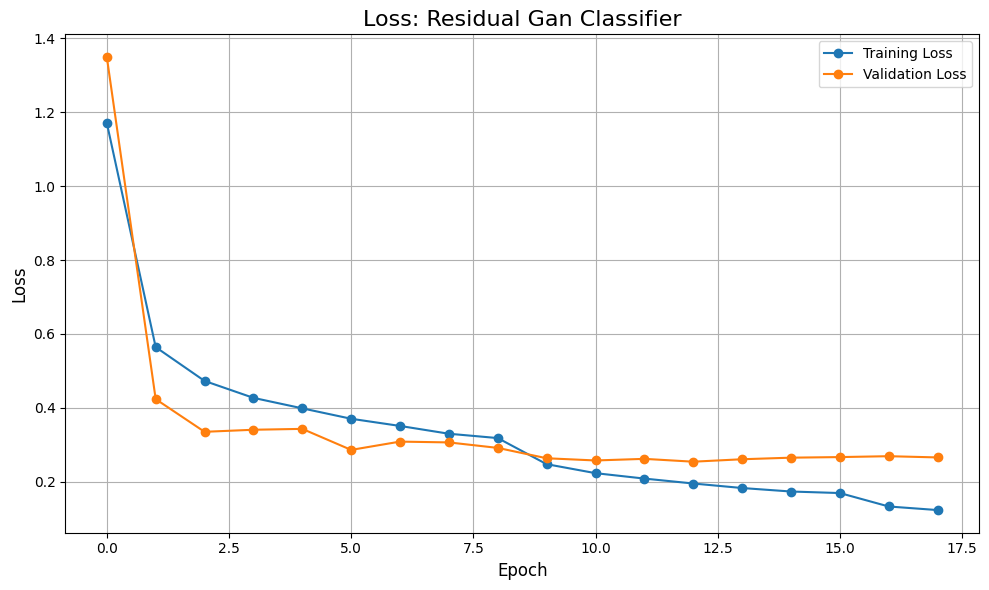

Loss plot saved to /kaggle/working/residual_gan_classifier/residual_gan_classifier_loss.png


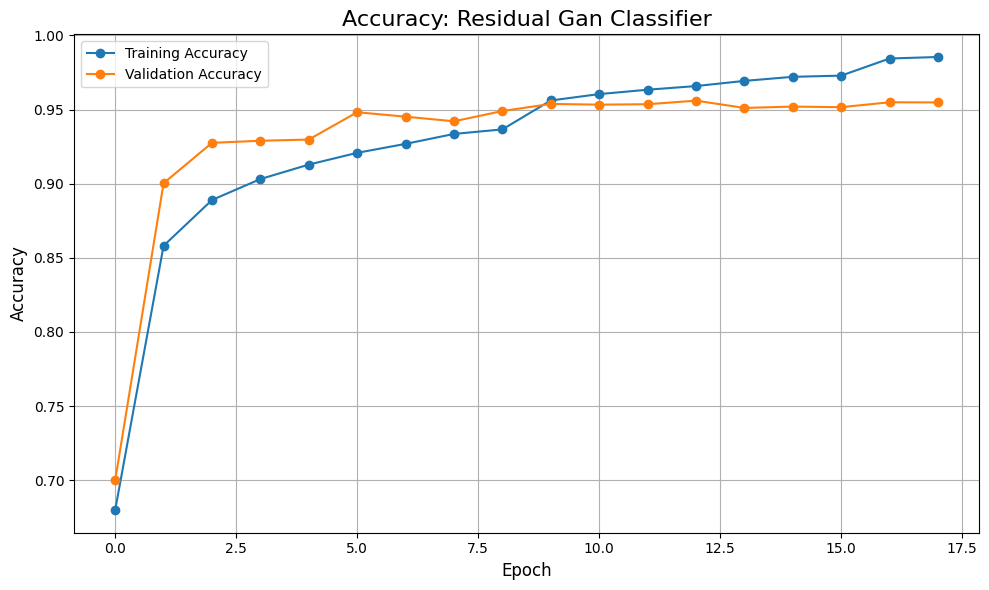

Accuracy plot saved to /kaggle/working/residual_gan_classifier/residual_gan_classifier_accuracy.png
Training history saved to /kaggle/working/residual_gan_classifier/training_history.pkl
Metadata saved to /kaggle/working/residual_gan_classifier/metadata_residual_gan_classifier.json


In [52]:
save_and_plot_results(history, model, model_name, saving_dir)

# Models Evaluation

In [53]:
class ModelEvaluator:
    def __init__(self, models_dir, test_data, test_labels, index_to_label, custom_objects=None, output_dir="output"):
        self.models_dir = models_dir
        self.X_test, self.y_test = test_data, test_labels
        self.index_to_label = index_to_label
        self.custom_objects = custom_objects
        self.output_dir = output_dir
        os.makedirs(self.output_dir, exist_ok=True)
        self.results = []
        self.df_results = None

    def _measure_inference_time(self, model, num_runs=10):
        """Evaluate the inference time of a model"""
        dummy_input = self.X_test[:1]
        
        # Dummy execution to startup the model
        _ = model.predict(dummy_input, verbose=0)
        
        start_time = time.time()
        for _ in range(num_runs):
            _ = model.predict(self.X_test, verbose=0, batch_size=64)
        end_time = time.time()
        
        avg_time_per_sample_ms = ((end_time - start_time) / num_runs / len(self.X_test)) * 1000
        return avg_time_per_sample_ms

    def _calculate_multiclass_auc(self, y_true, y_pred_proba, all_classes):
        """Computes AUC for the multi-class problem using OvR"""
        y_true_binarized = label_binarize(y_true, classes=all_classes)
        return roc_auc_score(y_true_binarized, y_pred_proba, multi_class='ovr', average='macro')

    def run_evaluation(self):
        model_folders = [d for d in os.listdir(self.models_dir) if os.path.isdir(os.path.join(self.models_dir, d))]

        for model_name in model_folders:
            print(f"\n--- Evaluating {model_name} ---")
            folder_path = os.path.join(self.models_dir, model_name)
            model_path = os.path.join(folder_path, f"{model_name}_best.keras")
            metadata_path = os.path.join(folder_path, f"metadata_{model_name}.json")

            if not (os.path.exists(model_path) and os.path.exists(metadata_path)):
                print(f"Skipping {model_name}: Missing model or metadata.")
                continue

            # Load Data
            try:
                model = load_model(model_path, custom_objects=self.custom_objects)
            except Exception as e:
                print(f"Error loading model {model_name}: {e}")
                continue
            
            with open(metadata_path, 'r') as f:
                metadata = json.load(f)

            # Metrics and predictions 
            y_pred_proba = model.predict(self.X_test, batch_size=64)
            y_pred = np.argmax(y_pred_proba, axis=1)
            
            report = classification_report(self.y_test, y_pred, target_names=self.index_to_label.values(), output_dict=True)
            
            inference_time = self._measure_inference_time(model)
            all_classes = list(range(len(self.index_to_label)))
            auc_score = self._calculate_multiclass_auc(self.y_test, y_pred_proba, all_classes)
            model_size_mb = round(os.path.getsize(model_path) / (1024 * 1024), 2)

            # Saves report
            report_path = os.path.join(self.output_dir, model_name, f"classification_report_{model_name}.json")
            os.makedirs(os.path.dirname(report_path), exist_ok=True)
            with open(report_path, 'w') as f:
                json.dump(report, f, indent=4)
            print(f"Classification report saved to {report_path}")

            # Update Metadata
            eval_results = {
                "model_name": metadata.get("model_name", model_name),
                "test_accuracy": report['accuracy'],
                "f1_macro": report['macro avg']['f1-score'],
                "precision_macro": report['macro avg']['precision'],
                "recall_macro": report['macro avg']['recall'],
                "auc_macro_ovr": auc_score,
                "num_params": metadata.get("num_params"),
                "model_size_mb": model_size_mb,
                "inference_time_ms_per_sample": inference_time
            }
            self.results.append(eval_results)

            # Confusion Matrix plots
            # self.plot_confusion_matrix(self.y_test, y_pred, model_name) Commented, I'll use it only on the best model.
        
        # Compute a Final Score based on different metrics
        if self.results:
            self.df_results = pd.DataFrame(self.results)
            self._calculate_final_score()
            self.plot_comparison_scatter()
            self.export_results_csv()

    def _calculate_final_score(self, weights=None):
        """Normalize the metrics and computes a final score for each model"""
        if weights is None:
            weights = {
                'f1_macro': 0.5,
                'test_accuracy': 0.2,
                'auc_macro_ovr': 0.1,
                'inference_time_ms_per_sample': -0.1,
                'model_size_mb': -0.1
            }
        
        df = self.df_results.copy()
        scaler = MinMaxScaler()
        
        score = np.zeros(len(df))
        for metric, weight in weights.items():
            scaled_metric = scaler.fit_transform(df[[metric]])
            if weight < 0:
                score += (1 - scaled_metric.flatten()) * abs(weight)
            else:
                score += scaled_metric.flatten() * weight
        
        self.df_results['final_score'] = score
        self.df_results = self.df_results.sort_values(by='final_score', ascending=False).reset_index(drop=True)

    def plot_confusion_matrix(self, y_true, y_pred, model_name):
        cm = confusion_matrix(y_true, y_pred)
        class_names = self.index_to_label.values()
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Confusion Matrix - {model_name.replace('_', ' ').title()}", fontsize=16)
        plt.xlabel("Predicted Label", fontsize=12)
        plt.ylabel("True Label", fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        
        save_path = os.path.join(self.output_dir, model_name, f"confusion_matrix_{model_name}.png")
        plt.savefig(save_path)
        plt.show()
        print(f"Confusion matrix saved to {save_path}")

    def plot_comparison_scatter(self):
        if self.df_results is None or self.df_results.empty:
            print("No results to plot.")
            return

        plt.style.use('seaborn-v0_8-whitegrid')
        
        # F1 Score vs. Inference Time
        fig, ax1 = plt.subplots(figsize=(12, 8))
        sns.scatterplot(data=self.df_results, x='inference_time_ms_per_sample', y='f1_macro', hue='model_name', s=200, ax=ax1, palette='viridis')
        ax1.set_title('Performance vs. Inference Time', fontsize=16)
        ax1.set_xlabel('Inference Time per Sample (ms)', fontsize=12)
        ax1.set_ylabel('F1 Score (Macro)', fontsize=12)
        for i, row in self.df_results.iterrows():
            ax1.text(row['inference_time_ms_per_sample'], row['f1_macro'], f" {row['model_name']}", fontsize=9)
        plt.legend(title='Model')
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "f1_vs_inference_time.png"))
        plt.show()

        # F1 Score vs. Model Size
        fig, ax2 = plt.subplots(figsize=(12, 8))
        sns.scatterplot(data=self.df_results, x='model_size_mb', y='f1_macro', hue='model_name', s=200, ax=ax2, palette='plasma')
        ax2.set_title('Performance vs. Model Size', fontsize=16)
        ax2.set_xlabel('Model Size (MB)', fontsize=12)
        ax2.set_ylabel('F1 Score (Macro)', fontsize=12)
        for i, row in self.df_results.iterrows():
            ax2.text(row['model_size_mb'], row['f1_macro'], f" {row['model_name']}", fontsize=9)
        plt.legend(title='Model')
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "f1_vs_model_size.png"))
        plt.show()

    def export_results_csv(self):
        if self.df_results is not None:
            output_path = os.path.join(self.output_dir, "evaluation_summary.csv")
            self.df_results.to_csv(output_path, index=False)
            print(f"\nEvaluation summary saved to: {output_path}")

In [54]:
def evaluate_and_compare_models():
    MODELS_DIR = "/kaggle/working"
    PROCESSED_DATA_DIR = "/kaggle/input/speechcommanddataset/processed_dataset"
    OUTPUT_DIR = "/kaggle/working/evaluation_output"

    test_path = os.path.join(PROCESSED_DATA_DIR, "test")
    test_ds, X_test, y_test = load_dataset(test_path, label_to_index, shuffle=False)

    custom_objects = {
        "Patches": Patches,
        "PatchEncoder": PatchEncoder,
        "PositionalEncoding": PositionalEncoding
    }

    evaluator = ModelEvaluator(
        models_dir=MODELS_DIR,
        test_data=X_test,
        test_labels=y_test,
        index_to_label=index_to_label,
        custom_objects=custom_objects,
        output_dir=OUTPUT_DIR
    )
    evaluator.run_evaluation()
    
    print("\n--- Final Model Ranking ---")
    print(evaluator.df_results)


--- Evaluating residual_cnn ---
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
Classification report saved to /kaggle/working/evaluation_output/residual_cnn/classification_report_residual_cnn.json

--- Evaluating vision_transformer ---
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Classification report saved to /kaggle/working/evaluation_output/vision_transformer/classification_report_vision_transformer.json

--- Evaluating hybrid_cnn_transformer ---
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step
Classification report saved to /kaggle/working/evaluation_output/hybrid_cnn_transformer/classification_report_hybrid_cnn_transformer.json

--- Evaluating baseline_cnn ---
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Classification report saved to /kaggle/working/evaluation_output/baseline_cnn/classification_report_baseline_cnn.json

--- Evaluating evaluation_output ---
Skipping evaluation_output: Missing model or metadata.

--- Evaluating cnn_bilstm ---
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Classification report saved to /kaggle/working/evaluation_output/cnn_bilstm/classification_report_cnn_bilstm.json

--- Evaluating residual_gan_classifier ---
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
Classification report saved to /kaggle/working/evaluation_output/residual_gan_classifier/classification_report_residual_gan_classifier.json


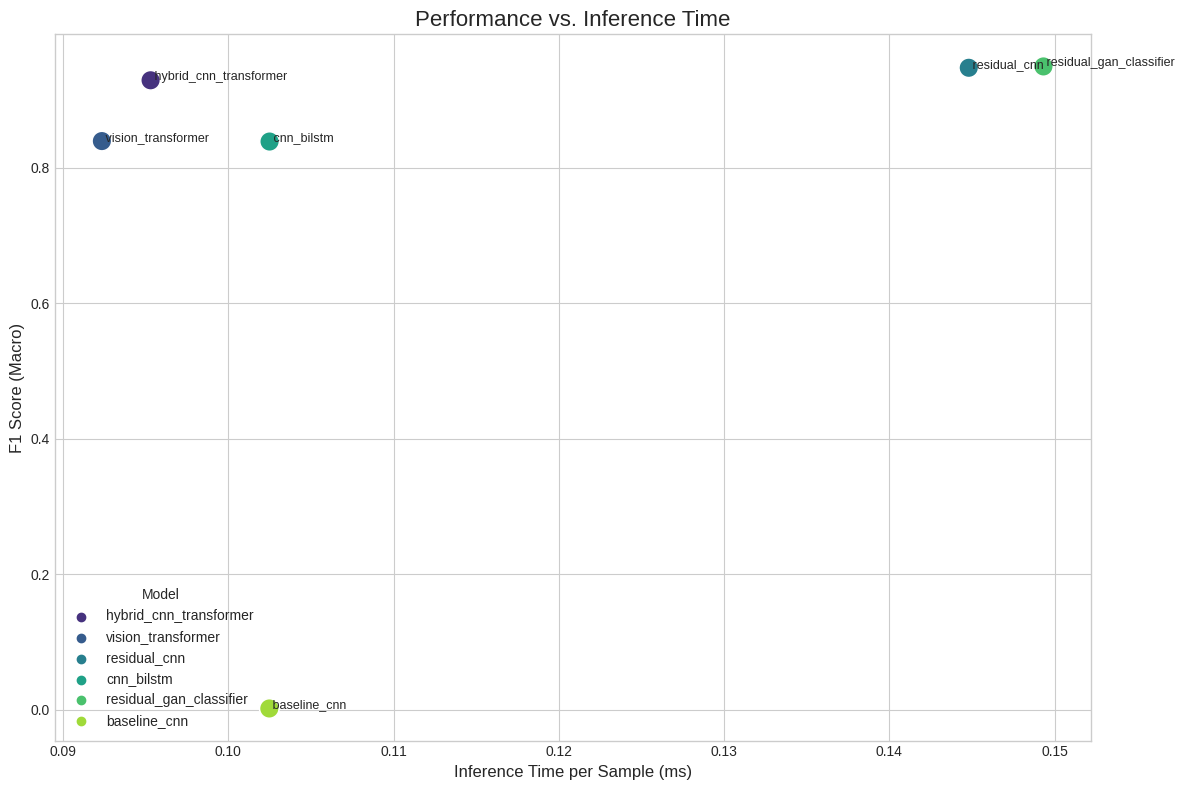

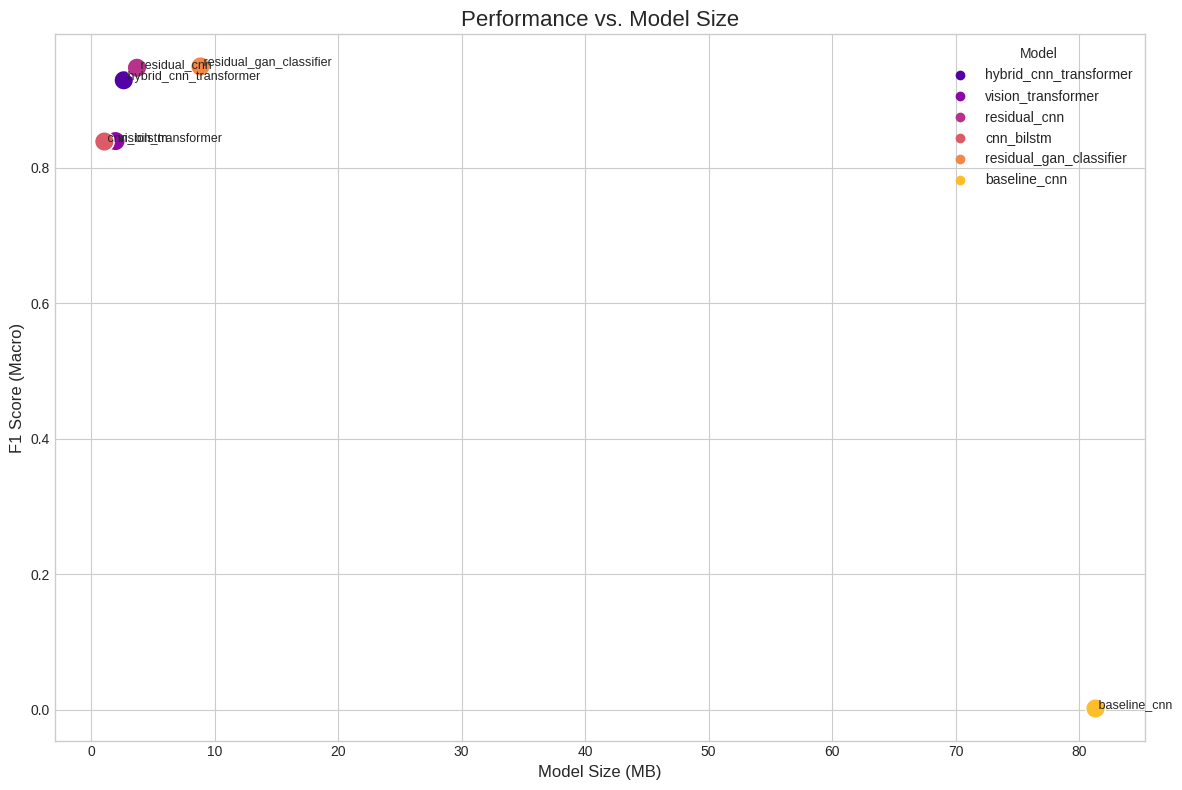


Evaluation summary saved to: /kaggle/working/evaluation_output/evaluation_summary.csv

--- Final Model Ranking ---
                model_name  test_accuracy  f1_macro  precision_macro  \
0   hybrid_cnn_transformer       0.937756  0.929188         0.926146   
1       vision_transformer       0.850432  0.839442         0.834461   
2             residual_cnn       0.953112  0.947645         0.948845   
3               cnn_bilstm       0.848978  0.838777         0.837041   
4  residual_gan_classifier       0.954203  0.949616         0.950752   
5             baseline_cnn       0.035984  0.001985         0.001028   

   recall_macro  auc_macro_ovr  num_params  model_size_mb  \
0      0.933696       0.999124      216547           2.65   
1      0.850346       0.995341      160483           1.98   
2      0.947587       0.999446      313315           3.72   
3      0.844200       0.994942       87523           1.08   
4      0.949270       0.999500      760547           8.86   
5      0.0285

In [55]:
evaluate_and_compare_models()